<a href="https://colab.research.google.com/github/vrmerchanr-arch/10932---Systematic-Analysis-of-Critical-Factors-for-Value-Management-in-Cybersecurity/blob/main/Resultados_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Figures set
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# IEEE Publication Style Parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold' # Set font to bold
plt.rcParams['axes.titleweight'] = 'bold' # Ensure title is also bold
plt.rcParams['axes.labelweight'] = 'bold' # Ensure labels are also bold
sns.set_theme(style='whitegrid', font='serif')

# Load the dataset
file_path = '/content/BASE DE DATOS - CSF de la gestion del valor.xlsx'
df = pd.read_excel(file_path)

# Data Preprocessing
df['Publication Year'] = pd.to_numeric(df['Publication Year'], errors='coerce')
df['Citations'] = pd.to_numeric(df['Citations'], errors='coerce').fillna(0)
print(f'Dataset successfully loaded: {len(df)} records.')

In [ ]:
# Content
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 3. Temporal Distribution of Publications
import matplotlib.pyplot as plt
import seaborn as sns

year_counts = df['Publication Year'].value_counts().sort_index()
plt.figure()
sns.lineplot(x=year_counts.index.astype(int), y=year_counts.values, marker='s', markersize=8, linewidth=2, color='#004488')
plt.title('Temporal distribution of academic publications', pad=20)
plt.xlabel('Publication year')
plt.ylabel('Number of articles')
plt.xticks(year_counts.index.astype(int))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 3. Temporal distribution of academic publications.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 3. Temporal distribution of academic publications.pdf', bbox_inches='tight')
plt.savefig('Fig. 3. Temporal distribution of academic publications.svg', bbox_inches='tight')

plt.show()

In [ ]:
# 7. Citation Correlation Analysis (Year vs. Citations)
correlation = df['Publication Year'].corr(df['Citations'])
plt.figure(figsize=(9, 6))
sns.regplot(x='Publication Year', y='Citations', data=df,
            scatter_kws={'alpha':0.5, 's':80, 'color':'#004488'},
            line_kws={'color':'#CC3311', 'linewidth':2})
plt.xlabel('Publication year')
plt.ylabel('Citation count')
plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 7. Correlation analysis.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 7. Correlation analysis.pdf', bbox_inches='tight')
plt.savefig('Fig. 7. Correlation analysis.svg', bbox_inches='tight')

plt.show()

In [ ]:
# @title
# 4. Top 10 Most Productive Authors (IEEE Double Column Width)
import matplotlib.ticker as ticker

# Procesamiento para mantener el formato 'Apellido, Nombre' al dividir solo por ';'
all_authors = df['Author'].astype(str).str.split(';').explode().str.strip().dropna()
all_authors = all_authors[all_authors != 'nan']

top_authors = all_authors.value_counts().head(10)

# Ajuste de tamaño para dos columnas IEEE (aprox 7 pulgadas de ancho)
plt.figure(figsize=(7, 5), dpi=600)
ax = sns.barplot(x=top_authors.values, y=top_authors.index, hue=top_authors.index, palette='mako', legend=False)

# Eliminación del título según lo solicitado
plt.xlabel('Publications', fontweight='bold')
plt.ylabel('Author', fontweight='bold')

# Ajustar la escala del eje X a pasos de 1
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 4. Productive authors.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 4. Productive authors.pdf', bbox_inches='tight')
plt.savefig('Fig. 4. Productive authors.svg', bbox_inches='tight')

plt.show()

## Advanced Bibliometric Analysis (English Analysis)

This section contains advanced statistical and machine learning insights focused on research impact, topic clustering, and predictive modeling.

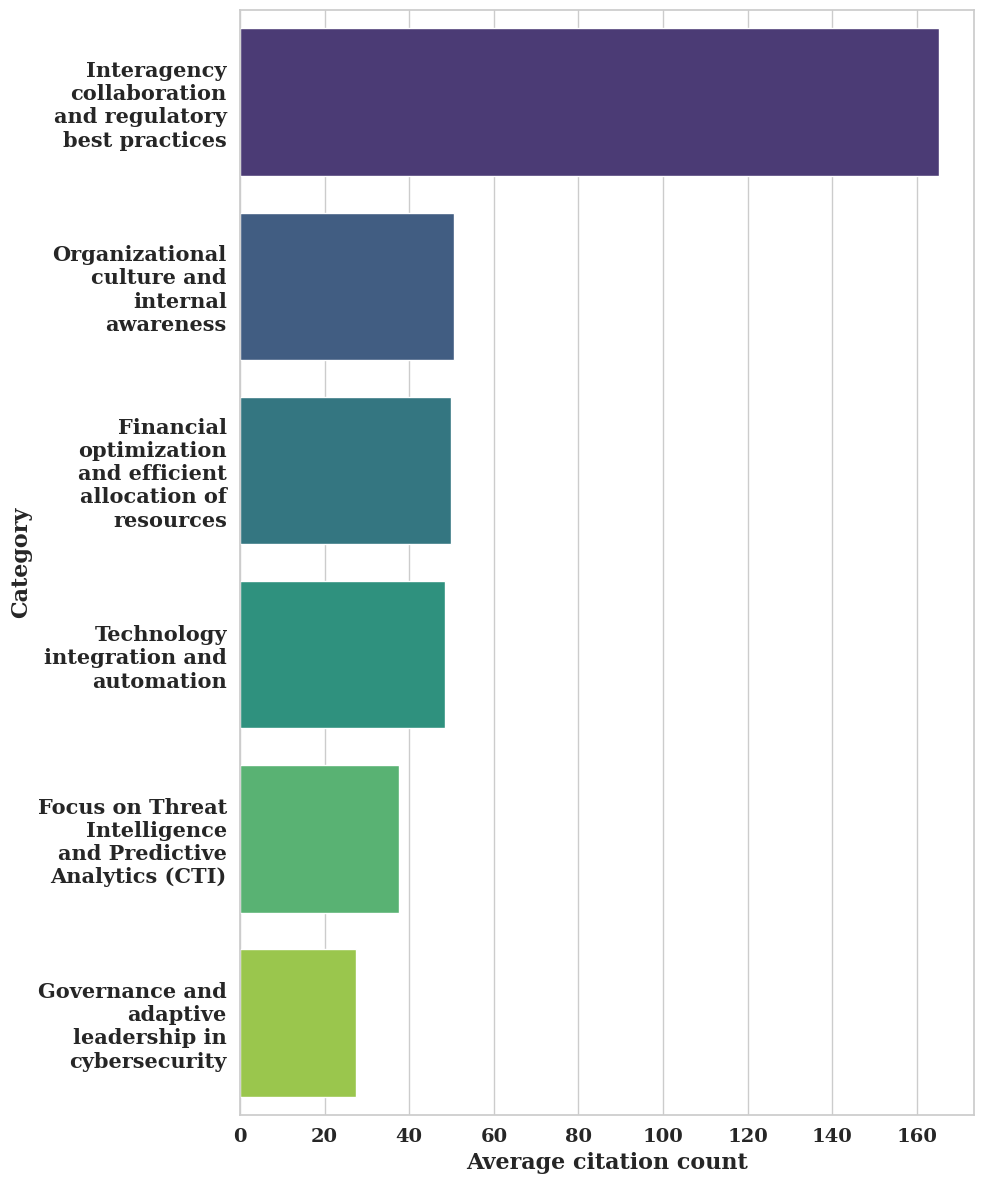

In [ ]:
# @title
# 5. Topic-Citation Correlation Analysis
import textwrap

# Increase figure height to 12 to allow for larger fonts and vertical expansion
plt.figure(figsize=(10, 12))
topic_impact = df.groupby('categoría recurrente')['Citations'].agg(['mean', 'count']).sort_values('mean', ascending=False)

# Wrap labels to ensure they are short and split into 2+ lines (max 15 characters per line)
wrapped_labels = [textwrap.fill(label, width=15) for label in topic_impact.index]

sns.barplot(x=topic_impact['mean'], y=wrapped_labels, hue=wrapped_labels, palette='viridis', legend=False)

# Formatting for scientific presentation with larger label sizes
plt.xlabel('Average citation count', fontweight='bold', fontsize=16)
plt.ylabel('Category', fontweight='bold', fontsize=16)

# Specifically increase the size of the category names on the Y-axis
plt.yticks(fontsize=15, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')

plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 8. Impact by category.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 8. Impact by category.pdf', bbox_inches='tight')
plt.savefig('Fig. 8. Impact by category.svg', bbox_inches='tight')

plt.show()

**Análisis:** Este gráfico muestra qué categorías de investigación están generando el mayor impacto promedio. Se observa que los temas de colaboración interinstitucional y cultura organizacional lideran la influencia académica en términos de citas.

In [ ]:
# @title
# 6. Clustering Analysis (K-Means)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features: Year and Citations
features = df[['Publication Year', 'Citations']].fillna(0)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Plot setup for IEEE High Definition
plt.figure(figsize=(9, 6), dpi=600)
sns.scatterplot(data=df, x='Publication Year', y='Citations', hue='Cluster', palette='viridis', s=120, style='Cluster', edgecolor='black', linewidth=1)

# Force bold labels and title for scientific publishing
# plt.title('Publication clustering based on age and impact', pad=20, fontweight='bold', fontsize=16)
plt.xlabel('Publication year', fontweight='bold', fontsize=14)
plt.ylabel('Citations', fontweight='bold', fontsize=14)

# Legend styling - Correction: using setp to apply bold weight to the title
leg = plt.legend(title='Cluster ID', prop={'weight':'bold'})
plt.setp(leg.get_title(), fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 11. Publication clustering based on age and impact.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 11. Publication clustering based on age and impact.pdf', bbox_inches='tight')
plt.savefig('Fig. 11. Publication clustering based on age and impact.svg', bbox_inches='tight')

plt.show()

**Análisis:** La segmentación identifica tres grupos claros: publicaciones recientes de bajo impacto, artículos consolidados con citas moderadas y valores atípicos (outliers) que representan hitos de alta citación en el campo.

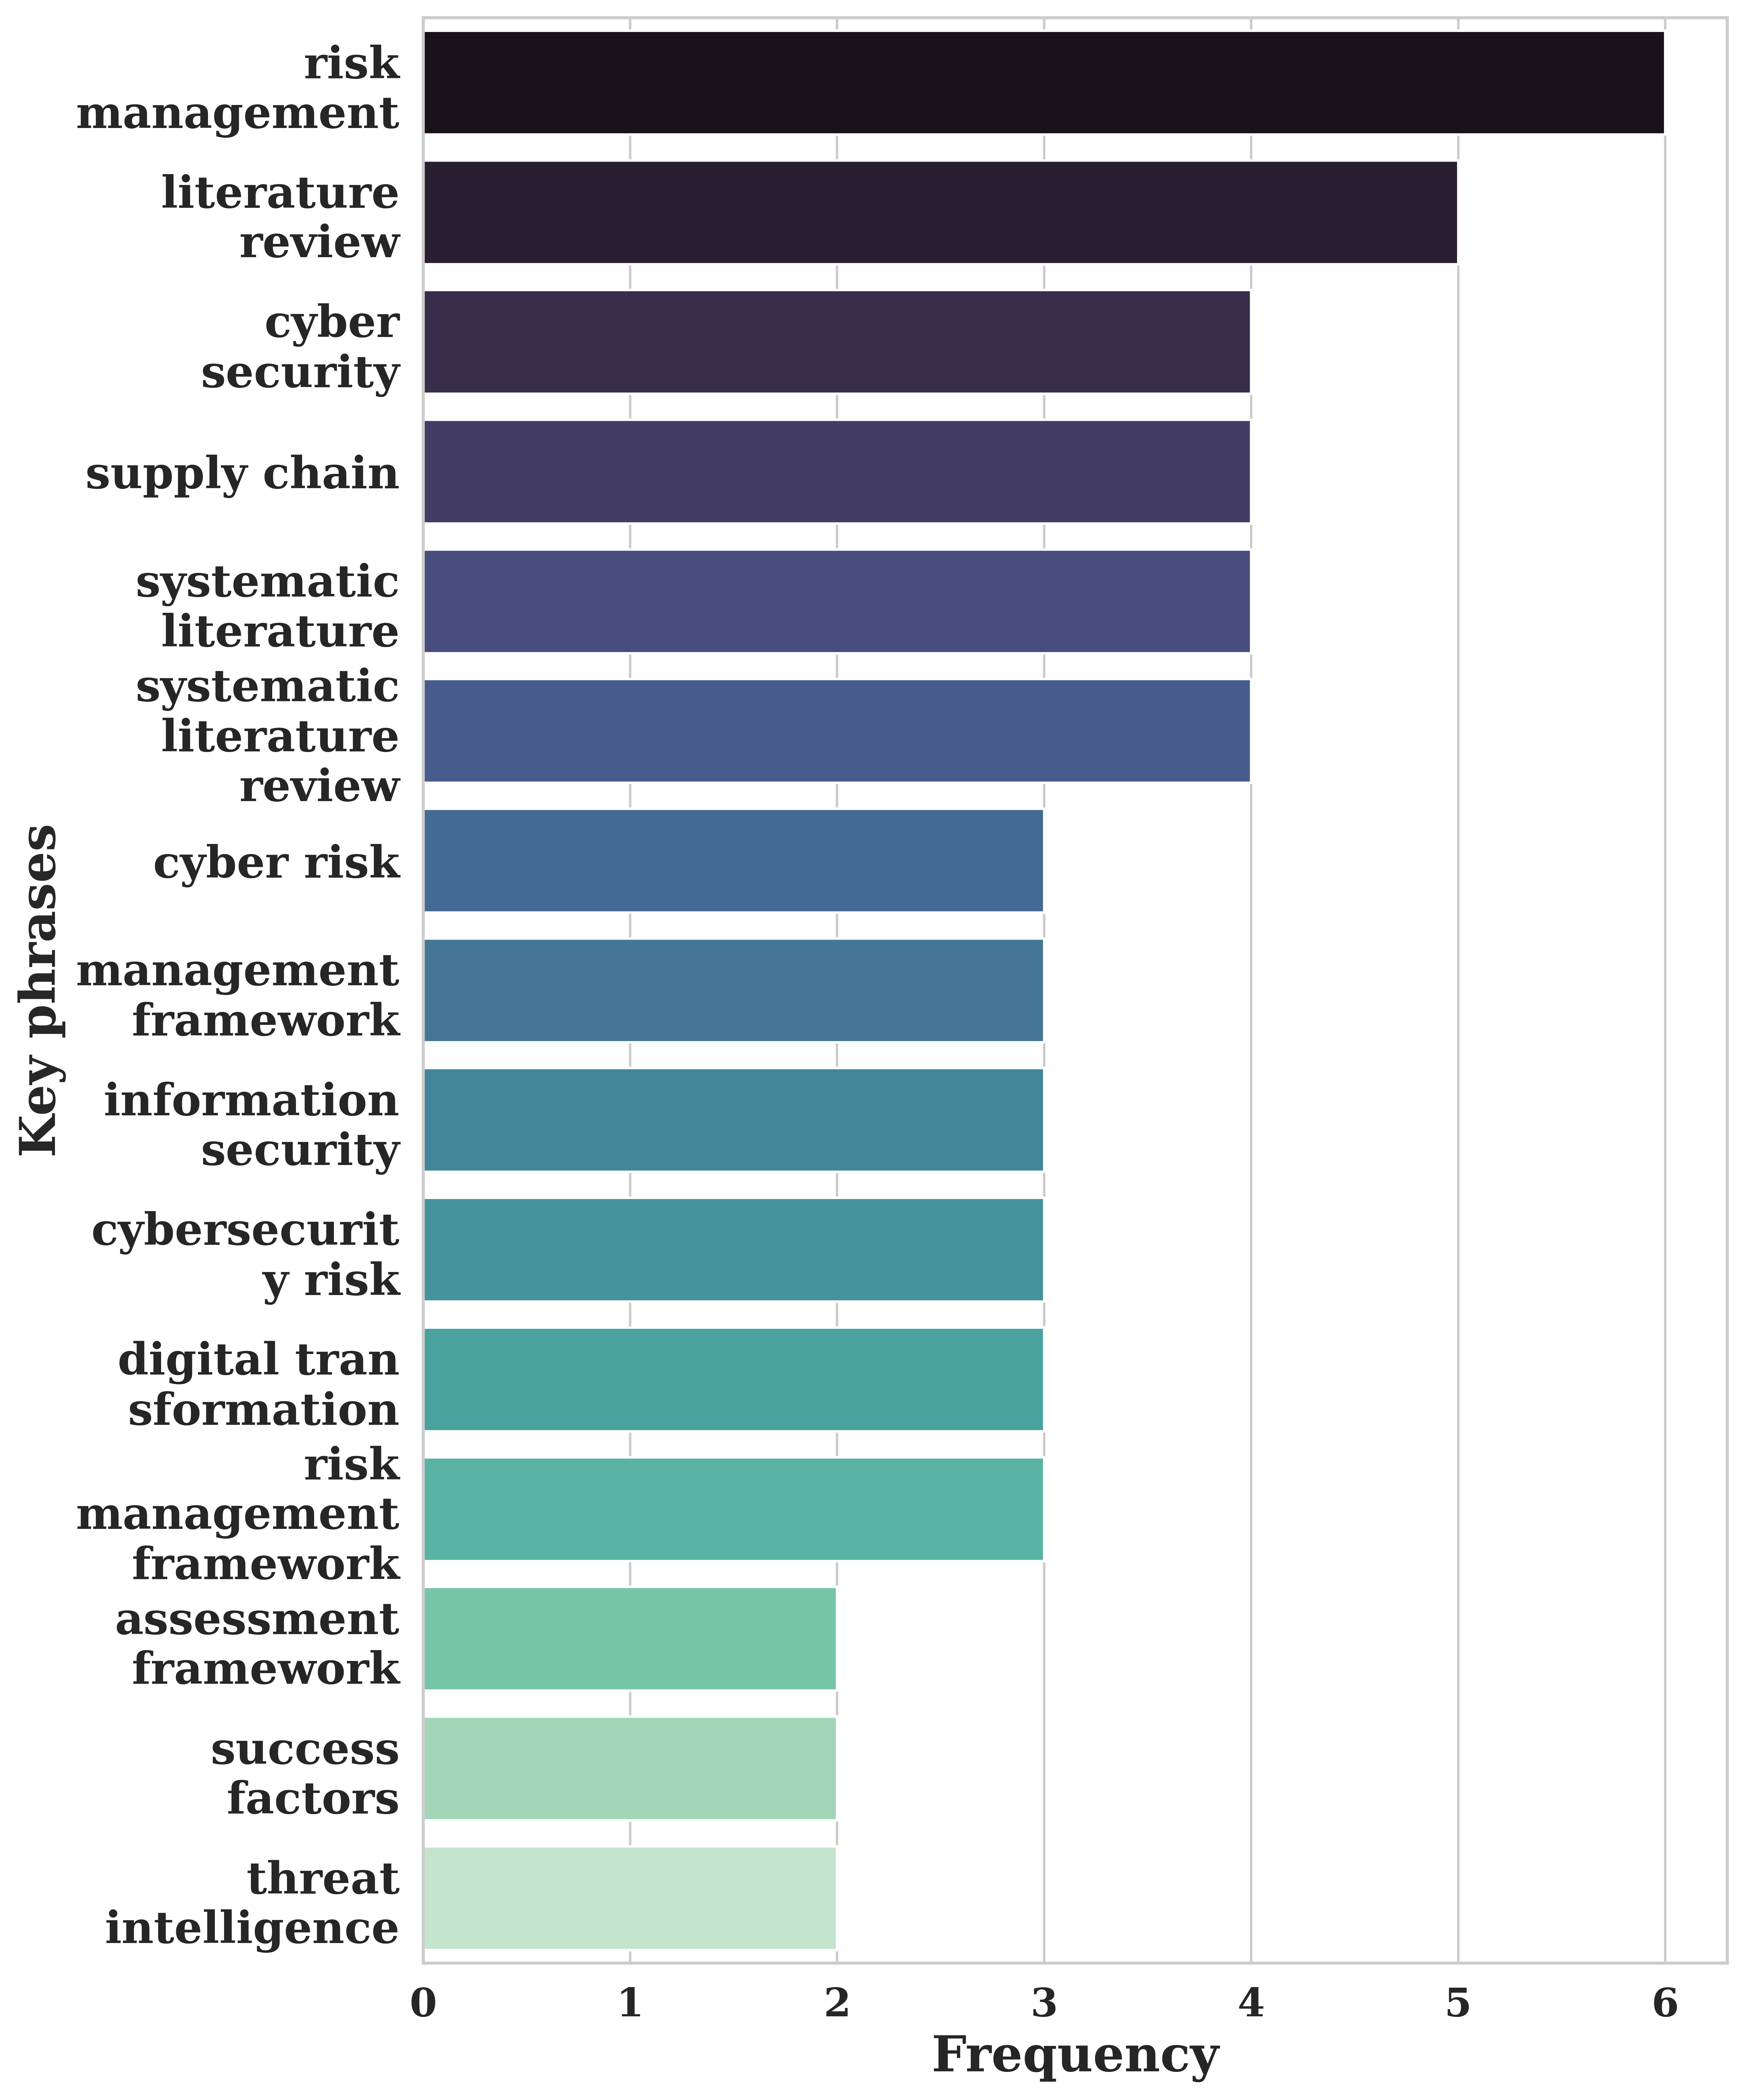

In [4]:
# @title
# 7. Text Mining for Emerging Topics (N-grams)
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import textwrap

# Fallback to 'Title' if 'Title' column is not found
text_col = 'Title' if 'Title' in df.columns else 'Item Type'
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 3), max_features=15)
ngrams = vectorizer.fit_transform(df[text_col].astype(str))
count_values = ngrams.toarray().sum(axis=0)
vocab = vectorizer.get_feature_names_out()

df_ngrams = pd.DataFrame({'Term': vocab, 'Frequency': count_values}).sort_values(by='Frequency', ascending=False)

# Force wrapping into two lines by reducing width and ensuring newline integration
df_ngrams['Term_Wrapped'] = [textwrap.fill(term, width=12) for term in df_ngrams['Term']]

# IEEE High Definition Setup
plt.figure(figsize=(10, 12), dpi=600)
sns.barplot(data=df_ngrams, x='Frequency', y='Term_Wrapped', hue='Term_Wrapped', palette='mako', legend=False)

# Larger labels and bold formatting
plt.xlabel('Frequency', fontweight='bold', fontsize=20)
plt.ylabel('Key phrases', fontweight='bold', fontsize=20)

# Specifically making the Y-axis labels (key phrases) larger
plt.yticks(fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.tight_layout()

# Save files
plt.savefig('Fig. 12. Emerging topics Discovery.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 12. Emerging topics Discovery.pdf', bbox_inches='tight')
plt.savefig('Fig. 12. Emerging topics Discovery.svg', bbox_inches='tight')

plt.show()

**Análisis:** La extracción de n-gramas revela que los términos recurrentes se centran en la gestión de riesgos y revisiones sistemáticas, indicando un enfoque metodológico fuerte en la literatura analizada.

In [ ]:
# @title
# 8. Author-Topic-Impact Matrix
expanded_df = df[['Author', 'categoría recurrente', 'Citations']].copy()
expanded_df['Author'] = expanded_df['Author'].str.split(';|,')
author_impact = expanded_df.explode('Author')
author_impact['Author'] = author_impact['Author'].str.strip()
author_impact = author_impact.dropna(subset=['Author'])

author_pivot = author_impact.groupby(['Author', 'categoría recurrente'])['Citations'].sum().unstack().fillna(0)
top_authors_list = author_impact.groupby('Author')['Citations'].sum().nlargest(15).index
filtered_pivot = author_pivot.loc[top_authors_list]

plt.figure(figsize=(12, 8))
sns.heatmap(filtered_pivot, annot=True, cmap='YlGnBu', fmt='.0f')
plt.title('Author-Category Impact Matrix (Top 15 Authors)', pad=20)
plt.xlabel('Research Category')
plt.ylabel('Author')
plt.tight_layout()

# Save in PNG, PDF, and SVG
plt.savefig('author_topic_matrix.png', dpi=300)
plt.savefig('author_topic_matrix.svg', bbox_inches='tight')
plt.show()

**Análisis:** Esta matriz multidimensional vincula a los autores más citados con sus temas de dominio, permitiendo identificar líderes de opinión en nichos específicos como la ciberseguridad o gobernanza.

In [ ]:
# @title
# 9. Citation Prediction Model (Feature Importance)
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

model_df = df[['Publication Year', 'categoría recurrente', 'Citations']].dropna()
le = LabelEncoder()
model_df['Cat_Encoded'] = le.fit_transform(model_df['categoría recurrente'])

X_feat = model_df[['Publication Year', 'Cat_Encoded']]
y_target = model_df['Citations']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_feat, y_target)

importances = rf_model.feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=['Publication Year', 'Topic Category'], hue=['Publication Year', 'Topic Category'], palette='viridis', legend=False)
plt.title('Feature Importance for Citation Prediction', pad=20, fontweight='bold')
plt.xlabel('Importance Score', fontweight='bold')
plt.tight_layout()

# Save in PNG, PDF, and SVG
plt.savefig('citation_prediction_model.png', dpi=300)
plt.savefig('citation_prediction_model.pdf', bbox_inches='tight')
plt.savefig('citation_prediction_model.svg', bbox_inches='tight')

plt.show()

**Análisis:** El modelo de aprendizaje automático sugiere que la temática (categoría) tiene una relevancia ligeramente superior al año de publicación para determinar el éxito en citaciones dentro de esta base de datos.

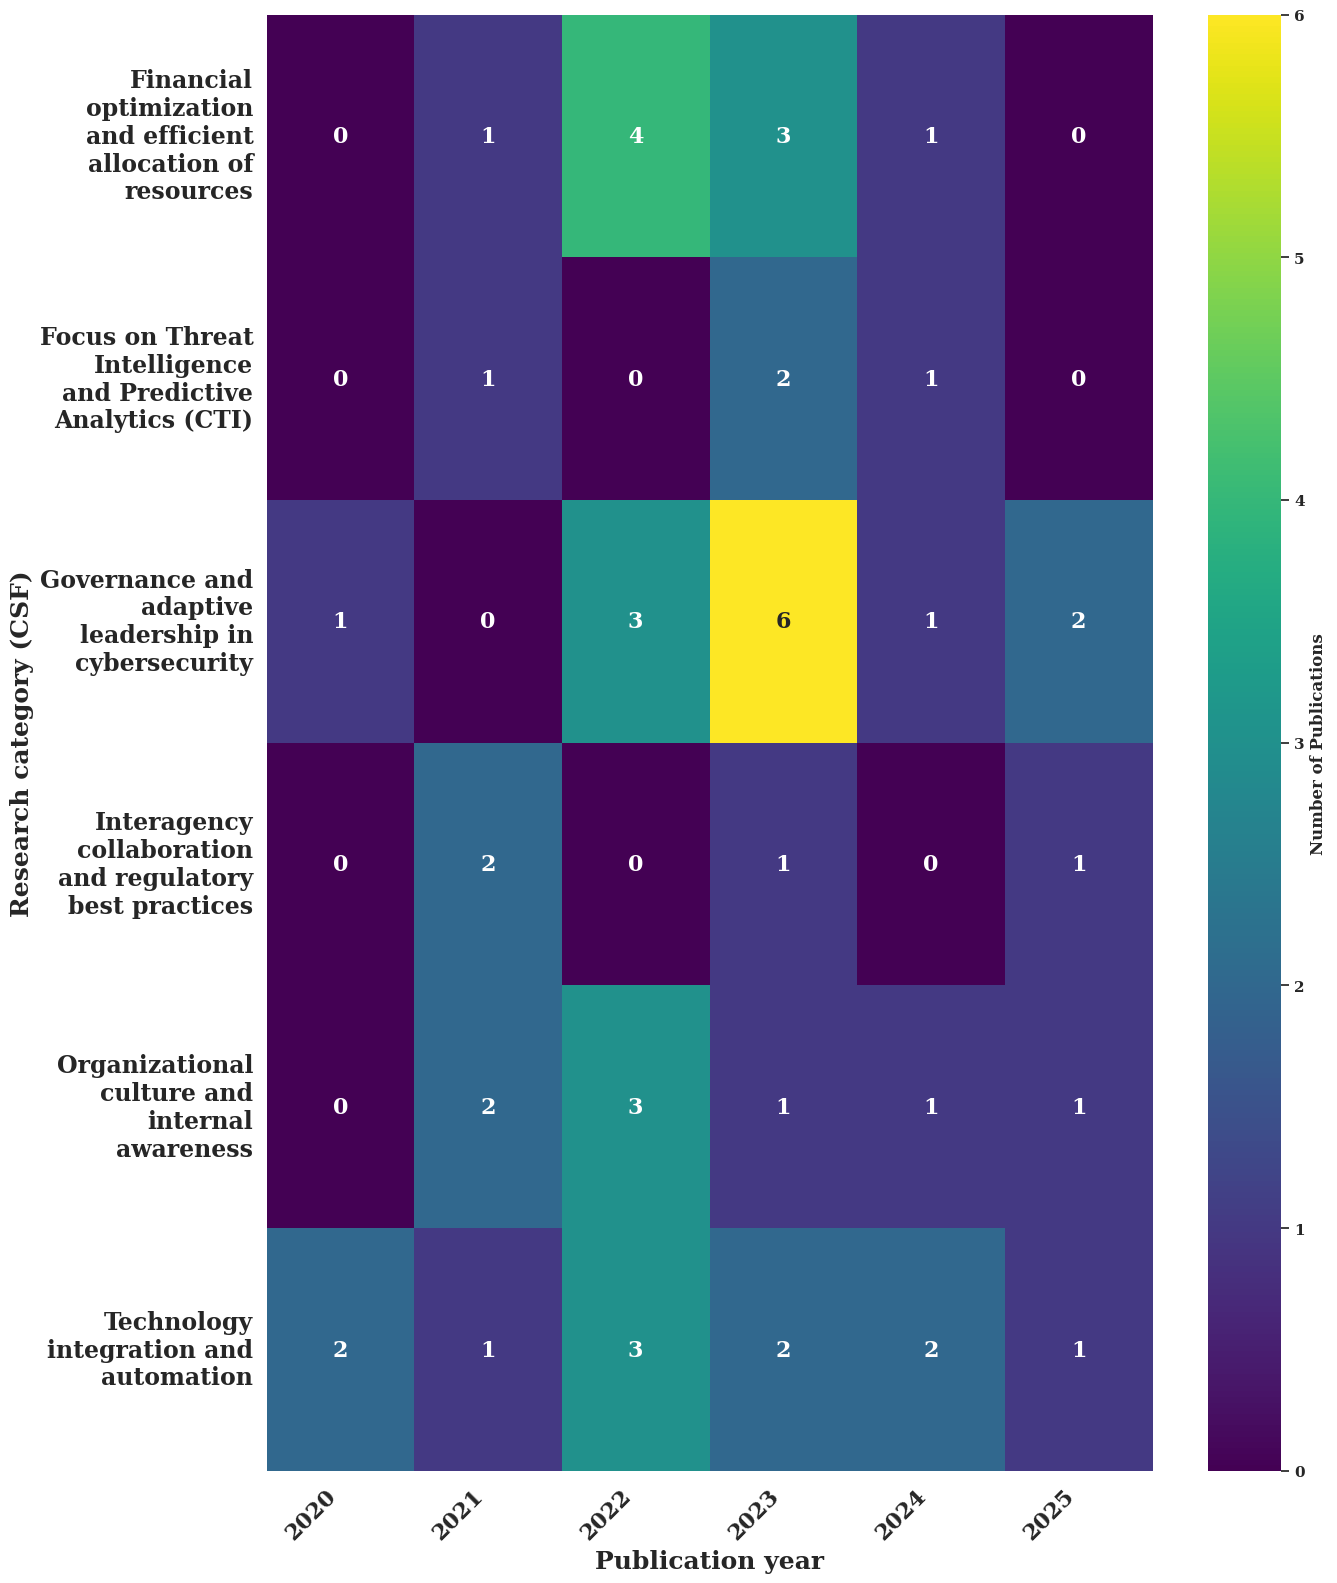

In [ ]:
# @title
# 10. Evolution of Critical Success Factors (CSF) by Year
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping by Year and Category to see frequency trends
evolution_df = df.groupby(['categoría recurrente', 'Publication Year']).size().unstack().fillna(0)

# Wrap index labels (categories) for better visibility (max 15 characters per line)
evolution_df.index = [textwrap.fill(label, width=15) for label in evolution_df.index]

# Increased height to 16 and width to 14 to accommodate larger text and horizontal orientation
plt.figure(figsize=(14, 16))

# Increased 'annot_kws' for larger numbers inside the heatmap
sns.heatmap(evolution_df, annot=True, cmap='viridis', fmt='.0f',
            annot_kws={"size": 16, "weight": "bold"},
            cbar_kws={'label': 'Number of Publications'})

# Formatting for scientific presentation with larger font sizes
plt.xlabel('Publication year', fontweight='bold', fontsize=18)
plt.ylabel('Research category (CSF)', fontweight='bold', fontsize=18)

# Specifically increase the size of the category names on the Y-axis (Horizontal orientation)
plt.yticks(fontsize=17, fontweight='bold', rotation=0)
plt.xticks(rotation=45, ha='right', fontsize=16, fontweight='bold')

plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 9. Evolution of critical success factors by year.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 9. Evolution of critical success factors by year.pdf', bbox_inches='tight')
plt.savefig('Fig. 9. Evolution of critical success factors by year.svg', bbox_inches='tight')

plt.show()

**Análisis:** El mapa de calor revela la transición de los temas de investigación. Se observa una concentración creciente en temas de 'Gobernanza y liderazgo adaptativo' en los años más recientes (2023-2024), lo que sugiere un cambio de enfoque desde la optimización técnica hacia la gestión estratégica y humana de la ciberseguridad.

In [ ]:
# @title
from wordcloud import WordCloud

# 11. Word Cloud Analysis of Publication Titles
text_data = ' '.join(df['Title'].astype(str).tolist())

# IEEE-style parameters for the Word Cloud
wordcloud = WordCloud(
    width=2000,
    height=1200,
    background_color='white',
    colormap='viridis',
    max_words=100,
    contour_width=1,
    contour_color='steelblue'
).generate(text_data)

# Increasing DPI to 600 for High Definition
plt.figure(figsize=(10, 6), dpi=600)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

# Applying bold weight to the title as requested
# plt.title('Word cloud of publication titles', pad=20, fontsize=18, fontweight='bold')

plt.tight_layout(pad=0)

# Save in PNG (High DPI), PDF (Vector format for IEEE), and SVG
plt.savefig('Fig. 10. World cloud of publication titles.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 10. World cloud of publication titles.pdf', bbox_inches='tight')
plt.savefig('Fig. 10. World cloud of publication titles.svg', bbox_inches='tight')

plt.show()

**Análisis:** La nube de palabras destaca conceptos centrales como 'Risk Management', 'Framework' y 'Success Factors'. Esto confirma que la literatura analizada se enfoca predominantemente en estructuras metodológicas para la gestión de riesgos y la identificación de elementos clave para el éxito organizacional en ciberseguridad.

In [ ]:
# @title
# 13. Citation Frequency Distribution (IEEE HD Optimized)
import matplotlib.pyplot as plt
import seaborn as sns

# Configure figure for IEEE High Definition (Full HD / 600 DPI)
plt.figure(figsize=(10, 6), dpi=600)

# Create a distribution plot (Histogram + KDE) using a scientific palette
sns.histplot(df['Citations'], kde=True, color='#264653', bins=15, alpha=0.7, edgecolor='black', linewidth=1.5)

# Explicit formatting for IEEE scientific standards (Negrilla/Bold)
# plt.title('Distribution Frequency of Citations', pad=20, fontweight='bold', fontsize=16)
plt.xlabel('Number of citations', fontweight='bold', fontsize=14)
plt.ylabel('Frequency (Article count)', fontweight='bold', fontsize=14)

# Customize grid and ticks with bold font
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Adjust layout to ensure no elements are clipped
plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format), and SVG
plt.savefig('Fig. 6. Distribution of citations.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 6. Distribution of citations.pdf', bbox_inches='tight')
plt.savefig('Fig. 6. Distribution of citations.svg', bbox_inches='tight')

plt.show()

**Análisis:** Esta gráfica de distribución permite observar el sesgo de citación en el corpus bibliográfico. La mayoría de los artículos presentan un número bajo de citas, mientras que la curva KDE suavizada identifica los rangos de impacto más comunes y resalta la presencia de trabajos altamente influyentes (outliers) en la cola derecha de la distribución.

In [ ]:
# @title
import matplotlib.pyplot as plt
import pandas as pd

# 14. Distribution of Journals (Pie Chart) - Based on 'Publication Title'
# Se utiliza la columna solicitada 'Publication Title' para el análisis
column_name = 'Publication Title'
journal_counts = df[column_name].value_counts().head(10) # Get top 10 journals

# Calculate percentages for the pie chart
labels = journal_counts.index
sizes = journal_counts.values

# Adding a 'Others' category for journals outside the top 10
other_count = df[column_name].value_counts().iloc[10:].sum()
if other_count > 0:
    labels = labels.tolist() + ['Others']
    sizes = sizes.tolist() + [other_count]

# Set up for IEEE High Definition
plt.figure(figsize=(10, 8), dpi=600)

# Create the pie chart following the style of the reference image
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})

# Ensure the pie chart is circular
plt.axis('equal')

plt.title('Distribution of Publications by Journal', pad=20, fontsize=18, fontweight='bold')

plt.tight_layout()

# Save in PNG (High DPI), PDF (Vector format), and SVG
plt.savefig('Fig. 5. Journal Distribution.png', dpi=600, bbox_inches='tight')
plt.savefig('Fig. 5. Journal Distribution.pdf', bbox_inches='tight')
plt.savefig('Fig. 5. Journal Distribution.svg', bbox_inches='tight')

plt.show()